# ***Welcome To This Project***
 **-> Here we will see the insights of my spotify listening data**

## Section 1 :- Data Preparation

-> We will clean the data in a proper csv

In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Load JSON file and convert to CSV
with open('Streaming_History_Audio_2022-2026.json', 'r', encoding='utf-8') as json_file:
    data = json.load(json_file)

# Convert to DataFrame
df = pd.DataFrame(data)
# Save to CSV
df.to_csv('Streaming_History_Audio_2022-2026.csv', index=False)

#clean data
df.drop(columns=['reason_start', 'reason_end', 'ip_addr', 'shuffle', 'skipped', 'offline', 
                 'offline_timestamp', 'incognito_mode', 'episode_name', 'audiobook_uri', 'audiobook_chapter_uri',
                 'spotify_track_uri', 'episode_show_name', 'spotify_episode_uri', 'audiobook_title', 'audiobook_chapter_title'], inplace=True)

df.rename(columns={'conn_country': 'Country', 'master_metadata_album_artist_name': 'Artist Name', 'master_metadata_track_name': 'Track Name', 
                   'master_metadata_album_album_name': 'Album Name'}, inplace=True)

df['ms_played'] = df['ms_played'] / 60000
df.rename(columns={'ms_played': 'minutes_played'}, inplace=True)

# Display first few rows
df.head()

,ts,platform,minutes_played,Country,Track Name,Artist Name,Album Name
0,2022-12-09T15:16:04Z,windows,0.119667,IN,Pathala Pathala,Anirudh Ravichander,Vikram
1,2022-12-09T15:16:31Z,windows,0.436500,IN,Vikram - Title Track,Anirudh Ravichander,Vikram
2,2022-12-09T15:19:33Z,windows,3.043467,IN,Wasted,Anirudh Ravichander,Vikram
3,2022-12-09T15:20:10Z,windows,0.593183,IN,Porkanda Singam,Anirudh Ravichander,Vikram
4,2022-12-09T15:25:52Z,windows,3.292833,IN,No Love - Slowed & Reverb,Kaushal Shekhawat,No Love


## Section 2 :- Analyzing Listening Behaviour


In [5]:
# Listening Behavior Overview
df['ts'] = pd.to_datetime(df['ts'])

total_minutes = df['minutes_played'].sum()
total_tracks = len(df)
active_days = df['ts'].dt.date.nunique()
avg_listening_per_day = total_minutes / active_days

print("=" * 50)
print("LISTENING BEHAVIOR OVERVIEW")
print("=" * 50)
print(f"Total Minutes Listened: {total_minutes:.2f} minutes ({total_minutes/60:.2f} hours)")
print(f"Total Tracks Played: {total_tracks:,}")
print(f"Active Listening Days: {active_days}")
print(f"Average Listening Per Day: {avg_listening_per_day:.2f} minutes")


LISTENING BEHAVIOR OVERVIEW
Total Minutes Listened: 22923.55 minutes (382.06 hours)
Total Tracks Played: 15,290
Active Listening Days: 396
Average Listening Per Day: 57.89 minutes


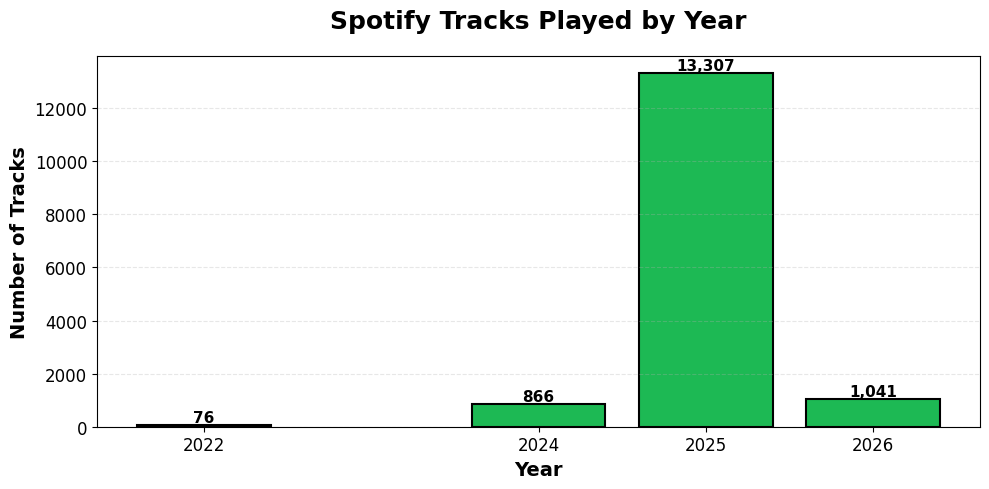

In [6]:
from io import BytesIO
from reportlab.platypus import Image

# Extract year from timestamp
df['Year'] = df['ts'].dt.year

# Count tracks by year
tracks_by_year = df['Year'].value_counts().sort_index()

# Create professional visualization
plt.figure(figsize=(10, 5))
bars = plt.bar(tracks_by_year.index, tracks_by_year.values, color='#1DB954', edgecolor='black', linewidth=1.5)

# Customize the plot
plt.title('Spotify Tracks Played by Year', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Number of Tracks', fontsize=14, fontweight='bold')
plt.xticks(tracks_by_year.index)
plt.tick_params(axis='both', labelsize=12)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Style improvements
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



### Listening in different platforms


In [7]:
#Listening On different platforms
df.groupby('platform').size().sort_values(ascending=False)


platform
android    13478
windows     1812
dtype: int64

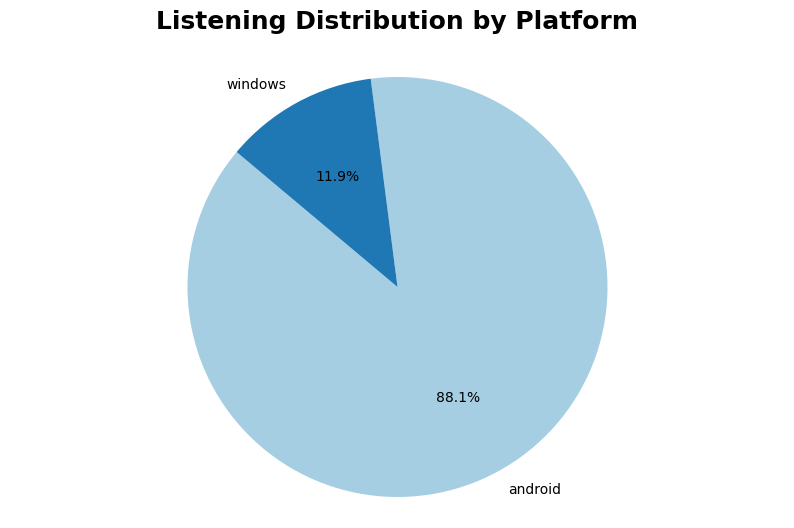

In [8]:
#Listening on different platforms visualization
platform_counts = df['platform'].value_counts() 
plt.figure(figsize=(10, 6))
bars = plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Listening Distribution by Platform', fontsize=18, fontweight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.  
plt.show()

In [ ]:
#Listening On different platforms

# Define label styling with improved colors and font size
label_style = {
    "font_size": 16,          # Larger, more readable font
    "color": "#2c3e50",       # Dark blue-gray for better contrast
    "background_color": "#ecf0f1",  # Light gray background
    "padding": "8px 12px",    # Add some padding around text
    "border_radius": "4px"    # Slightly rounded corners
}
sd


## Section 3 :- Top Prefrences 

### Top Artists


In [ ]:
#Top 15 Artists by Number of Tracks Played
print("=" * 50)
print("TOP 15 ARTISTS BY NUMBER OF TRACKS PLAYED")
print("=" * 50)
df.groupby('Artist Name').size().sort_values(ascending=False).head(15)

TOP 15 ARTISTS BY NUMBER OF TRACKS PLAYED


Artist Name
Playboi Carti     2501
The Weeknd        2497
Karan Aujla       1162
Kanye West        1040
Travis Scott       658
Lil Tecca          557
Shubh              420
Seedhe Maut        369
Drake              332
Frank Ocean        280
AP Dhillon         235
Don Toliver        229
Kendrick Lamar     218
Future             205
PARTYNEXTDOOR      193
dtype: int64

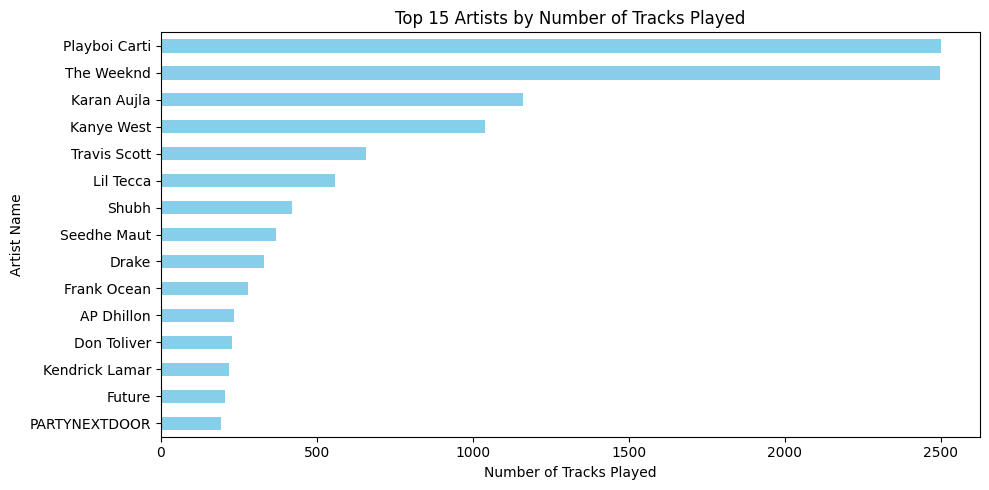

In [ ]:
# Top 15 Artists by Number of Tracks Played
plt.figure(figsize=(10, 5))
top_artists = df['Artist Name'].value_counts().head(15)    
top_artists.plot(kind='barh', color='skyblue')
plt.title('Top 15 Artists by Number of Tracks Played')
plt.xlabel('Number of Tracks Played')
plt.ylabel('Artist Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top Albums

In [ ]:
#Top 15 Albums by Number of Tracks Played
print("=" * 50)
print("TOP 15 ALBUMS BY NUMBER OF TRACKS PLAYED")
print("=" * 50)
df.groupby('Album Name').size().sort_values(ascending=False).head(15)

TOP 15 ALBUMS BY NUMBER OF TRACKS PLAYED


Album Name
MUSIC - SORRY 4 DA WAIT      1005
DOPAMINE                      540
MUSIC                         524
P-POP CULTURE                 518
Dawn FM                       507
Whole Lotta Red               366
Die Lit                       362
Graduation                    331
Starboy                       306
JACKBOYS 2                    295
Hurry Up Tomorrow             284
After Hours                   282
Beauty Behind The Madness     232
House Of Balloons             188
ASTROWORLD                    164
dtype: int64

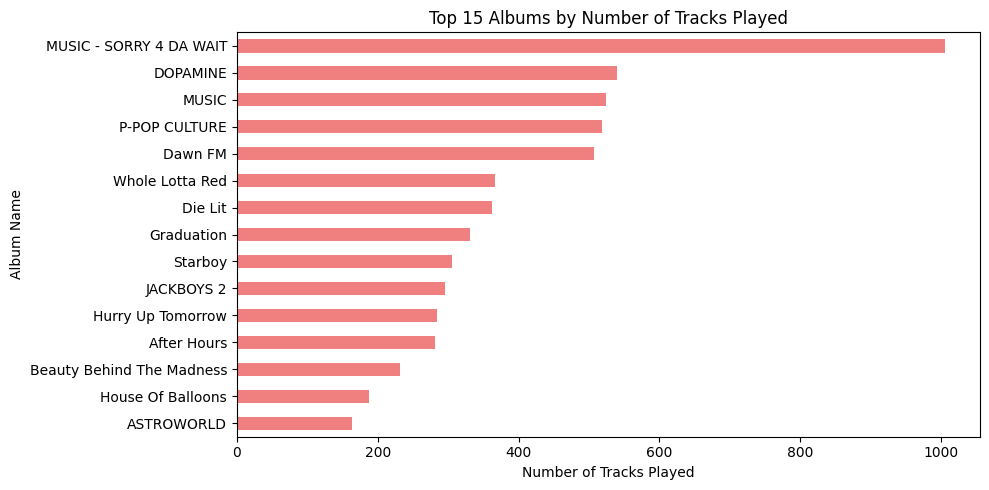

In [ ]:
# Top 15 Albums by Number of Tracks Played
plt.figure(figsize=(10, 5)) 
top_albums = df['Album Name'].value_counts().head(15)
top_albums.plot(kind='barh', color='lightcoral')
plt.title('Top 15 Albums by Number of Tracks Played')
plt.xlabel('Number of Tracks Played')   
plt.ylabel('Album Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Top Tracks

In [ ]:
# Top 15 Tracks by Number of Plays
print("=" * 50)
print("TOP 15 TRACKS BY NUMBER OF PLAYS")
print("=" * 50)
top_tracks = df.groupby('Track Name').size().sort_values(ascending=False).head(15)
print(top_tracks)


TOP 15 TRACKS BY NUMBER OF PLAYS
Track Name
48 Rhymes                                             151
Is There Someone Else?                                116
RATHER LIE (with The Weeknd)                          115
K POP                                                  93
2024                                                   83
EVIL J0RDAN                                            82
FOMDJ                                                  80
Sacrifice                                              78
POP OUT                                                77
Out of Time                                            74
I Really Do...                                         74
Can't Tell Me Nothing                                  73
Courtside                                              73
CHARGE DEM HOES A FEE (with Future & Travis Scott)     73
X Factor                                               71
dtype: int64


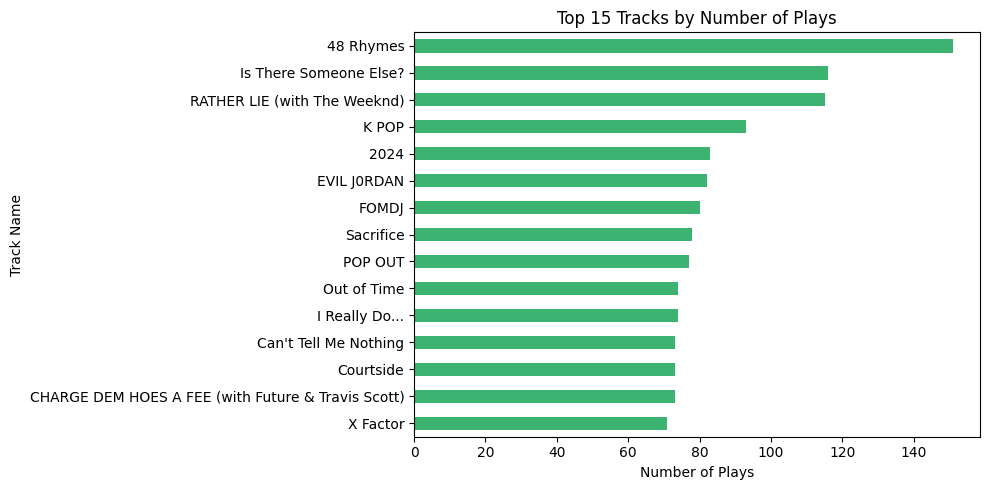

In [ ]:
# Top 15 Tracks by Number of Plays

plt.figure(figsize=(10, 5))
top_tracks = df['Track Name'].value_counts().head(15)   
top_tracks.plot(kind='barh', color='mediumseagreen')
plt.title('Top 15 Tracks by Number of Plays')
plt.xlabel('Number of Plays')
plt.ylabel('Track Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Section 4 :- Time Based Insights

### Most active time of the day

In [ ]:
# Most Active Listening Hours
df['Hour'] = df['ts'].dt.hour
hourly_listening = df['Hour'].value_counts().sort_index()
print(hourly_listening)

Hour
0       10
1       31
2       14
3      265
4      269
5      483
6      509
7      741
8      660
9      851
10    1023
11    1897
12    3155
13    1709
14    1168
15     724
16     560
17     549
18     448
19     141
20      56
21      19
22       6
23       2
Name: count, dtype: int64


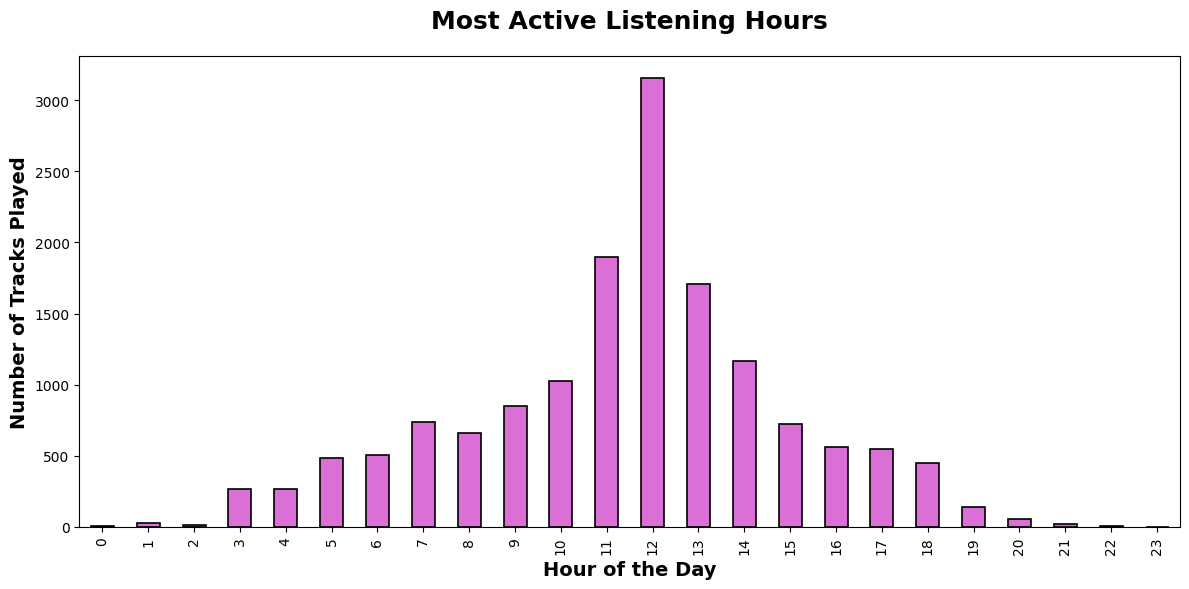

In [ ]:
# Most Active Listening Hours
plt.figure(figsize=(12, 6))
hourly_listening.plot(kind='bar', color='orchid', edgecolor='black', linewidth=1.2)
plt.title('Most Active Listening Hours', fontsize=18, fontweight='bold', pad=   20)
plt.xlabel('Hour of the Day', fontsize=14, fontweight='bold')
plt.ylabel('Number of Tracks Played', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**This is shows that that the most active listening takes place in the afternoon**

### Weekly listening report


In [ ]:
# Weekly Listening Patterns
df['Day of Week'] = df['ts'].dt.day_name()
weekly_listening = df['Day of Week'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print(weekly_listening)

Day of Week
Monday       1809
Tuesday      2329
Wednesday    2243
Thursday     2265
Friday       2479
Saturday     1966
Sunday       2199
Name: count, dtype: int64


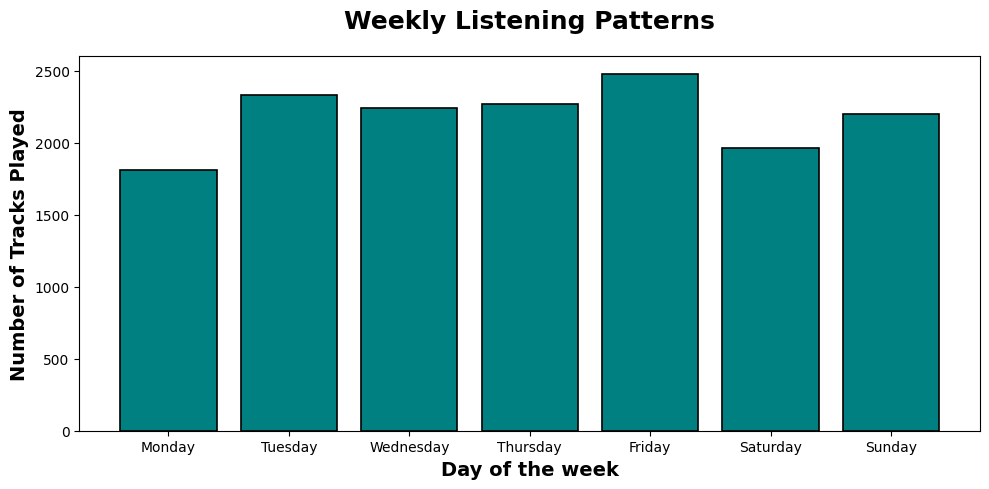

In [ ]:
# Weekly Listening Patterns
plt.figure(figsize=(10, 5))
plt.bar(weekly_listening.index, weekly_listening.values, color = "teal", edgecolor='black', linewidth=1.2)
plt.title('Weekly Listening Patterns', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Day of the week', fontsize=14, fontweight='bold')
plt.ylabel('Number of Tracks Played', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**This shows that the listening is almost consistent throughout the week**

## Section 5 :- Discovery Rate

In [ ]:
# Discovery of New Music
current_year = df['ts'].dt.year.max()

df['Is New Release'] = df['Year'] >= (current_year - 1)

new_music_count = df['Is New Release'].value_counts()
print("New vs Older Music:")
print(new_music_count)
print("\nPercentage breakdown:")
print(df['Is New Release'].value_counts(normalize=True) * 100)

New vs Older Music:
Is New Release
True     14348
False      942
Name: count, dtype: int64

Percentage breakdown:
Is New Release
True     93.839111
False     6.160889
Name: proportion, dtype: float64


([<matplotlib.patches.Wedge at 0x21e92685550>,
 [Text(0.7537253929374047, -0.9337548029549059, 'New Releases'),
  Text(-0.6909148142823148, 0.8559420070339081, 'Older Tracks')],
 [Text(0.4396731458801527, -0.544690301723695, '93.8%'),
  Text(-0.3768626259721717, 0.4668774583821316, '6.2%')])

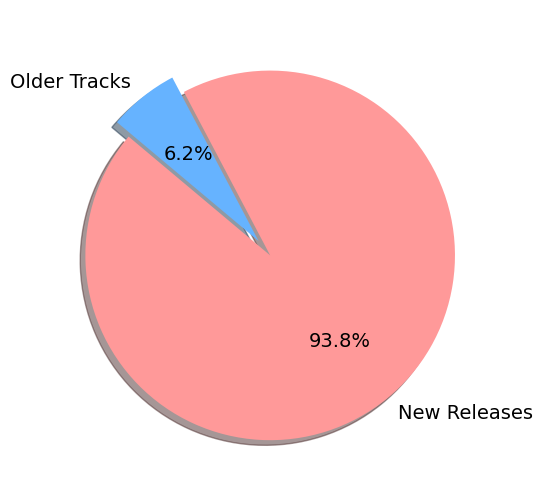

In [ ]:
# Discovery of New Music
plt.figure(figsize=(6, 6))
labels = ['New Releases', 'Older Tracks']
sizes = [new_music_count.get(True, 0), new_music_count.get(False, 0)]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the 1st slice
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 14})


**Most of the listening comes from songs released within 1 year of their release**

## Section 6 :- Summary

Based on your streaming history, you’re a routine-driven listener with strong artist loyalty.

**Recommendations**

1. **Branch Out From Your Favorites**  
   Playboi Carti and The Weeknd dominate your plays. Try Destroy Lonely, Ken Carson, or Weeknd collaborators for a similar vibe.

2. **Use Peak Times to Discover**  
   You’re most active at noon and on Fridays. Queue Spotify’s “New Music Daily” or genre playlists then to catch fresh tracks when you’re tuned in.

**Key Insights**

**Listening Behavior**  
- 22,924 min (382 h) across 15,290 tracks  
- 396 active days → 58 min/day average  

**Top Picks**  
- Artist: Playboi Carti (2,501 plays)  
- Album: *MUSIC – SORRY 4 DA WAIT* (1,005 plays)  
- Track: “48 Rhymes” (151 plays)  

**When You Listen**  
- Peak hour: 12 PM (3,155 plays)  
- Peak day: Friday (2,479 plays)  
- Consistent daily habit  

**Discovery**  
- 94 % new releases (< 1 year old)  
- 6 % older tracks  

**Summary**  
You favor fresh releases, listen every day, and spike on Friday afternoons.
